# Hangover — a quantitative teardown 🔬
### Base-rate vs conditional accuracy · the only informative cell · the exposure illusion · post-publication decay

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predicts the year?: Not supported](https://img.shields.io/badge/Predicts_the_year%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We score the January Barometer the only honest way — against the base rate — on the S&P 500, 1950–2025.

> ⚠️ **Not investment advice.** S&P 500 (^GSPC) monthly TR (Yahoo, daily→month-end), 1950–2025. Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (hangover/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from hangover import data, strategy as st
ret = data.fetch_index()              # cache-first; built by examples/verify.py --fetch
tbl = st.annual_table(ret)
cm  = st.conditional_means(tbl)
bar, bh = st.barometer_returns(tbl), st.buy_hold_roy(tbl)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | only the down-January cell informs (+2% vs +12%) |
| Tradability | **Mirage** | the rule just cuts equity exposure once a year |
| Predicts the year? | **Not supported** | 68% accuracy < 76% always-up base rate |

> 💡 *In plain words:* the omen's famous hit-rate is the market's hit-rate; it adds almost nothing.

## 1 · The claim, steelmanned

- **H₁:** rest-of-year mean and P(up) differ by the sign of January.
- **H₂ (the pitch):** sign(January) predicts sign(rest-of-year) better than the base rate.
- **H₃:** trading the omen beats simply holding the index.

## 2 · So what? — what rides on each

If H₂ holds, one month forecasts eleven — a free timing signal. If only a weak H₁ holds, it's a decayed seasonal tic mistaken for a forecast.

## 3 · How we'd know — the protocol

Collapse months → yearly (Jan, rest-of-year) → conditional means & P(up) → **directional accuracy vs base rate** → tradable cash-after-down rule vs buy-and-hold → pre/post-1972 decay split.

## 4 · The teardown

### 4.1 Conditional means and the base rate

In [2]:
display(cm.round(4))
print(f"base rate P(up) = {st.base_rate(tbl):.1%}; accuracy = {st.barometer_accuracy(tbl):.1%}")

,n,roy_mean,p_up
jan_up,46.0,0.1224,0.8696
jan_down,30.0,0.0207,0.6000
unconditional,76.0,0.0823,0.7632


base rate P(up) = 76.3%; accuracy = 68.4%


> 💡 *In plain words:* after a down January the year still averages **+2%** and is up **60%** of the time. The 'bad omen' is barely bad.

### 4.2 The base-rate illusion, quantified

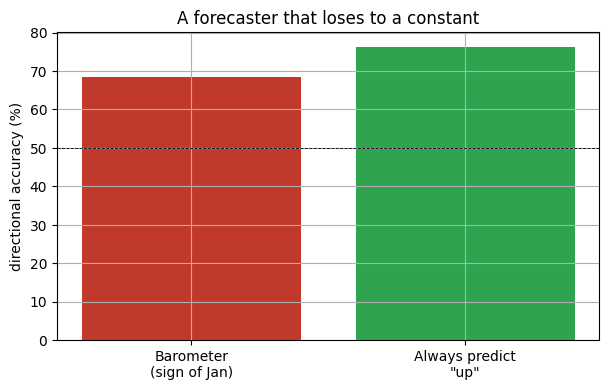

In [3]:
acc, base = st.barometer_accuracy(tbl), st.base_rate(tbl)
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['Barometer\n(sign of Jan)','Always predict\n"up"'],[acc*100,base*100],color=['#c0392b','#2ea44f'])
ax.set_ylabel('directional accuracy (%)'); ax.set_title('A forecaster that loses to a constant'); ax.axhline(50,color='k',lw=.6,ls='--'); plt.show()

> 💡 *In plain words:* if your predictor is beaten by a sticky note that says "up", it isn't a predictor. **H₂ rejected.**

### 4.3 The tradable version — it just holds less stock

In [4]:
rows={'Buy & hold (Feb-Dec)':st.summary(bh),'Barometer (cash if Jan down)':st.summary(bar)}
display(pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown','hit_rate']].round(3))
yrs_in_cash=int((tbl['jan']<=0).sum()); print(f'years the rule sits in cash: {yrs_in_cash}/{len(tbl)}')

,cagr,sharpe,max_drawdown,hit_rate
Buy & hold (Feb-Dec),0.072,0.568,-0.403,0.763
Barometer (cash if Jan down),0.069,0.693,-0.160,0.526


years the rule sits in cash: 30/76


> 💡 *In plain words:* higher Sharpe, lower drawdown — bought entirely by being out of the market ~40% of down-January years. A permanently lower equity weight does the same. **H₃ rejected.**

### 4.4 Post-publication decay

In [5]:
for lab,sl in [('1950-1972',tbl[tbl.index<=1972]),('1973-on',tbl[tbl.index>1972])]:
    s=sl; print(f'{lab}: accuracy {st.barometer_accuracy(s):.1%}, jan-down rest-of-year {s[s.jan<=0]["roy"].mean():+.2%}')

1950-1972: accuracy 78.3%, jan-down rest-of-year -0.44%
1973-on: accuracy 64.2%, jan-down rest-of-year +2.98%


> 💡 *In plain words:* sharpest before Hirsch named it (a down January once preceded a flat year), faded after — the McLean–Pontiff fade.

## 5 · The verdict

H₁ weakly holds, H₂ and H₃ rejected → Signal `WEAK`, Tradability `MIRAGE`, the year-ahead claim `NOT SUPPORTED`.

## 6 · Could you trade it?

Only as a once-a-year de-risking switch — which is not timing, and is dominated by simply choosing your equity weight on purpose.

## 7 · Going further

Forks: (a) the "Other January Effect" (Cooper et al. 2006) on a size cross-section; (b) condition on January *magnitude* not just sign; (c) multiple-testing correction across all twelve "X-month barometers" — the calendar is full of them. Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).